# Text Mining Assignment 1

### Loading Dataset

In [1]:
from sklearn.datasets import fetch_20newsgroups

categories = [
    "alt.atheism",
    "comp.graphics", 
    "comp.os.ms-windows.misc", 
    "comp.sys.ibm.pc.hardware", 
    "comp.sys.mac.hardware", 
    "comp.windows.x", 
    "misc.forsale", 
    "rec.autos", 
    "rec.motorcycles", 
    "rec.sport.baseball", 
    "rec.sport.hockey", 
    "sci.crypt", 
    "sci.electronics",
    "sci.med", 
    "sci.space", 
    "soc.religion.christian", 
    "talk.politics.guns", 
    "talk.politics.mideast", 
    "talk.politics.misc",
    "talk.religion.misc",
]


def size_mb(docs):
    return sum(len(s.encode("utf-8")) for s in docs) / 1e6

First we load the dataset utilising the heuristics provided by sklearn to remove message metadata:

In [2]:
from time import time

data_train = fetch_20newsgroups(
    subset="train",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes"),
)

data_test = fetch_20newsgroups(
    subset="test",
    categories=categories,
    shuffle=True,
    random_state=42,
    remove=("headers", "footers", "quotes"),
)

target_names = data_train.target_names

data_train_size_mb = size_mb(data_train.data)
data_test_size_mb = size_mb(data_test.data)

print(
    f"{len(data_train.data)} documents - "
    f"{data_train_size_mb:.2f}MB (training set)"
)
print(f"{len(data_test.data)} documents - {data_test_size_mb:.2f}MB (test set)")
print(f"{len(target_names)} categories")

11314 documents - 13.78MB (training set)
7532 documents - 8.26MB (test set)
20 categories


Since the targets/labels doesn't need to get vectorized, we can extract them now.

In [3]:
y_train, y_test = data_train.target, data_test.target

### Vectorizer Function

Next we define a function to vectorize the train and test data based on three types of features: count, tf, and tf-idf. 

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

def vectorize_dataset(data_train, data_test, feature="count", **vectorizer_params):
    """ Vectorise dataset based on certain feature.
    
    Args:
        feature: "count", "tf", or "tfidf". Decides which sklearn vectorizer is used. 
        vectorizer_params: optional params passed to the sklearn vectorizer.
    
    Returns:
        vectorised train and test datasets, the feature names, and the vectorizer used.
    """
    if feature == "count":
        vectorizer = CountVectorizer(**vectorizer_params)
    elif feature == "tf":
        vectorizer = TfidfVectorizer(use_idf=False, **vectorizer_params)
    elif feature == "tfidf":
        vectorizer = TfidfVectorizer(use_idf=True, **vectorizer_params)
    else:
        raise ValueError(f"feature must be 'count', 'tf' or 'tfidf', got {feature}")
        
    
    t0 = time()
    X_train = vectorizer.fit_transform(data_train.data)
    duration_train = time() - t0
    
    t0 = time()
    X_test = vectorizer.transform(data_test.data)
    duration_test = time() - t0
    
    feature_names = vectorizer.get_feature_names_out()
    
    print(
        f"vectorizing train_dataset done in {duration_train:.3f}s "
        f"at {data_train_size_mb / duration_train:.3f}MB/s"
    )
    print(f"n_samples: {X_train.shape[0]}, n_features: {X_train.shape[1]}")
    print(
        f"vectorizing test_dataset done in {duration_test:.3f}s "
        f"at {data_test_size_mb / duration_test:.3f}MB/s"
    )
    print(f"n_samples: {X_test.shape[0]}, n_features: {X_test.shape[1]}")
    
    return X_train, X_test, feature_names, vectorizer

### Comparing Classifiers 

In this section we will compare three classification models. Since it is not specified in the assignment, we will use the TfidfVectorizer with the same parameters as the tutorial when comparing the classifiers. 

In [5]:
X_train, X_test, feature_names, vectorizer = vectorize_dataset(data_train, data_test, "tfidf", sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")

vectorizing train_dataset done in 0.880s at 15.653MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.459s at 18.008MB/s
n_samples: 7532, n_features: 17797


The three models we will compare will be Logistic Regression, K-Nearest Neighbor, and LinearSVC.

In [6]:
from sklearn import metrics
from sklearn.utils.extmath import density

def benchmark(clf, X_train, X_test, y_train=y_train, y_test=y_test, custom_name=False):
    """Fit clf on the train data and evaluate it on the test data.

    Args:
        clf: unfitted scikit-learn classifier.
        X_train, X_test: training and testing features.
        y_train y_test: training and testing labels.
        custom_name: label for the results table (defaults to the class name).

    Returns:
        dict with name, accuracy, macro precision/recall/F1, and train/test times.
    """
    print("Training: ")
    print(clf)
    t0 = time()
    clf.fit(X_train, y_train)
    train_time = time() - t0
    print(f"train time: {train_time:.3f}s")

    t0 = time()
    pred = clf.predict(X_test)
    test_time = time() - t0
    print(f"test time:  {test_time:.3f}s")

    score = metrics.accuracy_score(y_test, pred)
    print(f"accuracy:   {score:.3f}")
    
    p, r, f1, _ = metrics.precision_recall_fscore_support(
       y_test, pred, average="macro", zero_division=0
    )
    print(f"precision:  {p:.3f}")
    print(f"recall:  {r:.3f}")
    print(f"f1:  {f1:.3f}")

    if hasattr(clf, "coef_"):
        print(f"dimensionality: {clf.coef_.shape[1]}")
        print(f"density: {density(clf.coef_)}")
        print()

    print()
    result = {
        "name": custom_name or clf.__class__.__name__,
        "accuracy": metrics.accuracy_score(y_test, pred),
        "precision": p,
        "recall": r,
        "f1": f1,
        "train_time": train_time,
        "test_time": test_time,
    }
    return result

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC

results = []
for clf, name in (
    (LogisticRegression(C=5, max_iter=1000), "Logistic Regression"),
    (KNeighborsClassifier(n_neighbors=1000), "kNN"),
    # L2 penalty Linear SVC
    (LinearSVC(C=0.1, dual=False, max_iter=1000), "Linear SVC")
):
    print(name)
    results.append(benchmark(clf, X_train, X_test, custom_name=name))


Logistic Regression
Training: 
LogisticRegression(C=5, max_iter=1000)
train time: 2.538s
test time:  0.000s
accuracy:   0.683
precision:  0.682
recall:  0.672
f1:  0.673
dimensionality: 17797
density: 1.0


kNN
Training: 
KNeighborsClassifier(n_neighbors=1000)
train time: 0.000s
test time:  1.433s
accuracy:   0.611
precision:  0.655
recall:  0.593
f1:  0.582

Linear SVC
Training: 
LinearSVC(C=0.1, dual=False)
train time: 0.885s
test time:  0.004s
accuracy:   0.695
precision:  0.693
recall:  0.680
f1:  0.678
dimensionality: 17797
density: 1.0




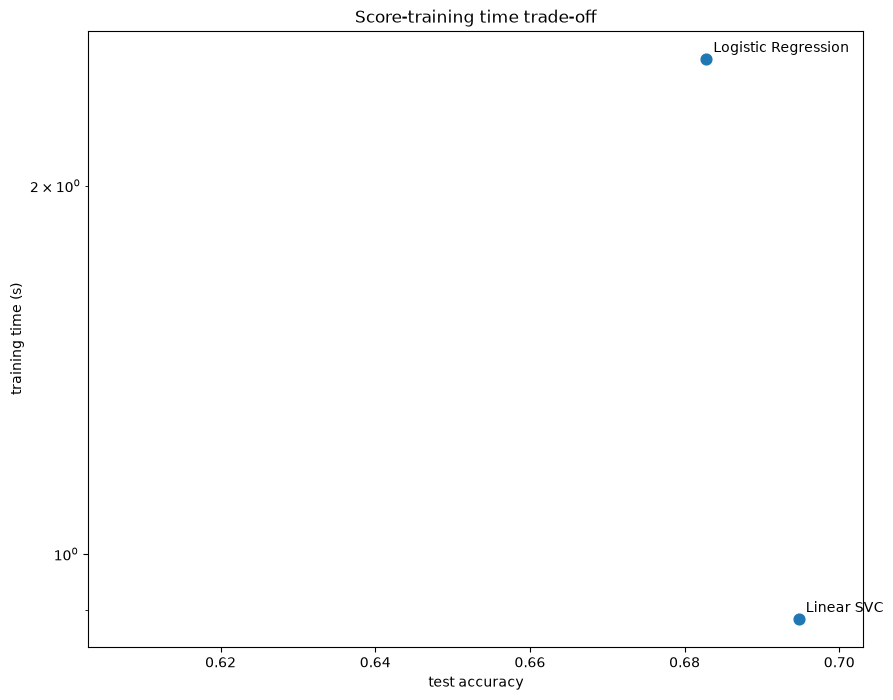

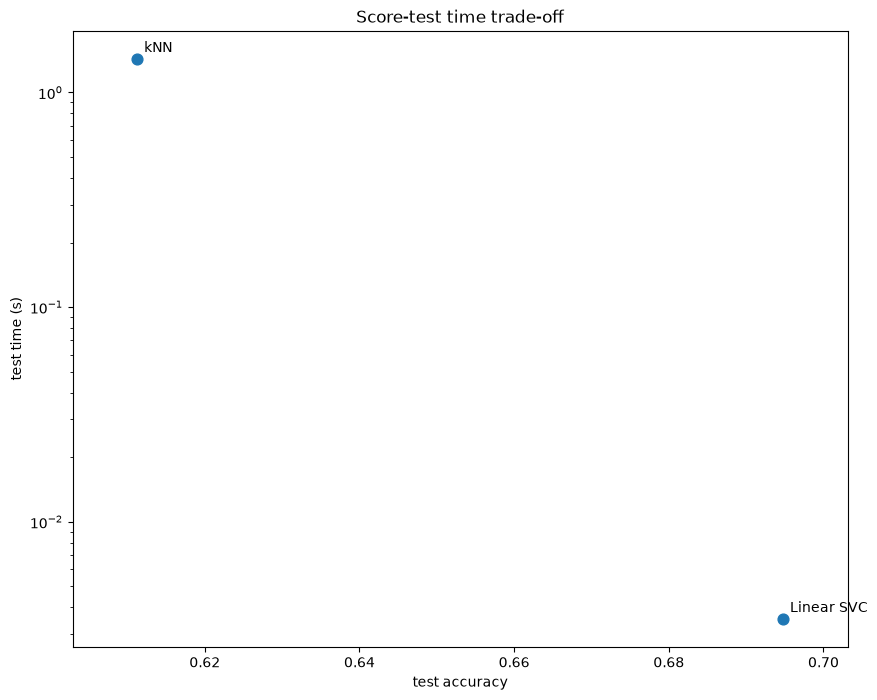

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)

def tradeoff_plot(df, time_col, title, ylabel):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(df["accuracy"], df[time_col], s=60)
    ax.set(title=title, yscale="log", xlabel="test accuracy", ylabel=ylabel)
    for _, row in df.iterrows():
        ax.annotate(row["name"], (row["accuracy"], row[time_col]),
                    xytext=(5, 5), textcoords="offset points")
    ax.margins(x=0.1)
    return fig

tradeoff_plot(df, "train_time", "Score-training time trade-off", "training time (s)")
tradeoff_plot(df, "test_time", "Score-test time trade-off", "test time (s)")
plt.show()

### Comparing Features (count, tf, tfidf) Across Classifiers

In this section we will compare three features i.e. methods of vectorising the train/test datasets, by using the three classification models from the previous section. First lets use the CountVectorizer:

In [9]:
X_train_count, X_test_count, _, _ = vectorize_dataset(data_train, data_test, "count", max_df=0.5, min_df=5, stop_words="english")
X_train_tf, X_test_tf, _, _ = vectorize_dataset(data_train, data_test, "tf", sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")
X_train_tfidf, X_test_tfidf, _, _ = vectorize_dataset(data_train, data_test, "tfidf", sublinear_tf=True, max_df=0.5, min_df=5, stop_words="english")

vectorizing train_dataset done in 0.872s at 15.801MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.468s at 17.650MB/s
n_samples: 7532, n_features: 17797
vectorizing train_dataset done in 0.859s at 16.052MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.480s at 17.205MB/s
n_samples: 7532, n_features: 17797
vectorizing train_dataset done in 0.888s at 15.518MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.483s at 17.112MB/s
n_samples: 7532, n_features: 17797


In [10]:
classifiers = {
    "Logistic Regression": LogisticRegression(C=5, max_iter=1000),
    "kNN": KNeighborsClassifier(n_neighbors=1000),
    "Linear SVC": LinearSVC(C=0.1, dual=False, max_iter=1000),
}

vectorized_datasets = [
    ("count", X_train_count, X_test_count),
    ("tf", X_train_tf, X_test_tf),
    ("tfidf", X_train_tfidf, X_test_tfidf),
]

results = []
for name, clf in classifiers.items():
    for feature, X_train, X_test in vectorized_datasets:
        print(feature)
        result = benchmark(clf, X_train, X_test, custom_name=name)
        result["feature"] = feature
        results.append(result)
        
df = pd.DataFrame(results)

count
Training: 
LogisticRegression(C=5, max_iter=1000)
train time: 4.734s
test time:  0.006s
accuracy:   0.601
precision:  0.601
recall:  0.591
f1:  0.593
dimensionality: 17797
density: 1.0


tf
Training: 
LogisticRegression(C=5, max_iter=1000)
train time: 3.935s
test time:  0.006s
accuracy:   0.655
precision:  0.654
recall:  0.644
f1:  0.645
dimensionality: 17797
density: 1.0


tfidf
Training: 
LogisticRegression(C=5, max_iter=1000)
train time: 2.491s
test time:  0.010s
accuracy:   0.683
precision:  0.682
recall:  0.672
f1:  0.673
dimensionality: 17797
density: 1.0


count
Training: 
KNeighborsClassifier(n_neighbors=1000)
train time: 0.002s
test time:  1.343s
accuracy:   0.115
precision:  0.590
recall:  0.110
f1:  0.083

tf
Training: 
KNeighborsClassifier(n_neighbors=1000)
train time: 0.006s
test time:  1.236s
accuracy:   0.530
precision:  0.594
recall:  0.513
f1:  0.503

tfidf
Training: 
KNeighborsClassifier(n_neighbors=1000)
train time: 0.002s
test time:  1.206s
accuracy:   0.611
p

c:\Users\chinm\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


train time: 52.972s
test time:  0.006s
accuracy:   0.628
precision:  0.624
recall:  0.617
f1:  0.617
dimensionality: 17797
density: 1.0


tf
Training: 
LinearSVC(C=0.1, dual=False)
train time: 0.938s
test time:  0.002s
accuracy:   0.669
precision:  0.665
recall:  0.654
f1:  0.651
dimensionality: 17797
density: 1.0


tfidf
Training: 
LinearSVC(C=0.1, dual=False)
train time: 0.818s
test time:  0.009s
accuracy:   0.695
precision:  0.693
recall:  0.680
f1:  0.678
dimensionality: 17797
density: 1.0




In [11]:
print(df)

                  name  accuracy  precision    recall        f1  train_time  \
0  Logistic Regression  0.600770   0.600923  0.590943  0.592670    4.734059   
1  Logistic Regression  0.655204   0.653507  0.643686  0.644751    3.935436   
2  Logistic Regression  0.682820   0.681712  0.671771  0.672832    2.491230   
3                  kNN  0.115109   0.590302  0.109980  0.082693    0.002152   
4                  kNN  0.530005   0.593779  0.513484  0.503446    0.006101   
5                  kNN  0.611259   0.655389  0.592617  0.581959    0.002000   
6           Linear SVC  0.627589   0.623522  0.616774  0.617071   52.972116   
7           Linear SVC  0.668747   0.665422  0.654057  0.651085    0.938350   
8           Linear SVC  0.694769   0.693272  0.680219  0.677592    0.817922   

   test_time feature  
0   0.006012   count  
1   0.005576      tf  
2   0.010287   tfidf  
3   1.343159   count  
4   1.236198      tf  
5   1.205898   tfidf  
6   0.006009   count  
7   0.001855      tf  
8 

### TfidfVectorizer Params Experimentation

In this section we will narrow in on the TfidfVectorizer, experimenting with its different parameters to see which one performs the best.

In [12]:
best_clf = LinearSVC(C=0.1, dual=False, max_iter=1000)
best_clf_name = "Linear SVC (C=0.1)"

def run_tfidf_experiment(param_name, param_grid, base_params, clf, clf_name):
    """
    Evaluates a set of parameter options for TfidfVectorizer on the best classifier.
    """
    exp_results = []
    print(f"\n\nExperimenting with Parameter: {param_name}\n")
    
    for val in param_grid:
        current_params = base_params.copy()
        
        if param_name == "analyzer_ngram":
            analyzer_val, ngram_val = val
            current_params["analyzer"] = analyzer_val
            current_params["ngram_range"] = ngram_val
            display_val = f"analyzer='{analyzer_val}', ngram_range={ngram_val}"
        else:
            current_params[param_name] = val
            display_val = str(val)
            
        print(f"Testing {param_name} = {display_val} ...")
        
        #Vectorize
        X_tr, X_te, _, _ = vectorize_dataset(data_train, data_test, feature="tfidf", **current_params)
        
        #Benchmark
        res = benchmark(clf, X_tr, X_te, custom_name=f"{clf_name} ({param_name}={display_val})")
        res[param_name] = display_val
        exp_results.append(res)
        
    return exp_results

#TfidfVectorizer parameters
base_vectorizer_params = {
    "sublinear_tf": True,
    "max_df": 0.5,
    "min_df": 5,
    "stop_words": "english"
}

#Lowercasing, True vs False
lowercase_results = run_tfidf_experiment(
    param_name="lowercase",
    param_grid=[True, False],
    base_params=base_vectorizer_params,
    clf=best_clf,
    clf_name=best_clf_name
)

#stop_word, None vs "english"
stopwords_results = run_tfidf_experiment(
    param_name="stop_words",
    param_grid=[None, "english"],
    base_params=base_vectorizer_params,
    clf=best_clf,
    clf_name=best_clf_name
)

#analyzer in combination with ngram_range
analyzer_ngram_results = run_tfidf_experiment(
    param_name="analyzer_ngram",
    param_grid=[
        ("word", (1, 1)),
        ("word", (1, 2)),
        ("char", (3, 5)),
        ("char_wb", (3, 5)),
    ],
    base_params=base_vectorizer_params,
    clf=best_clf,
    clf_name=best_clf_name
)

#max_features
max_features_results = run_tfidf_experiment(
    param_name="max_features",
    param_grid=[1000, 5000, 10000, 20000, None],
    base_params=base_vectorizer_params,
    clf=best_clf,
    clf_name=best_clf_name
)



Experimenting with Parameter: lowercase

Testing lowercase = True ...
vectorizing train_dataset done in 0.880s at 15.669MB/s
n_samples: 11314, n_features: 17797
vectorizing test_dataset done in 0.459s at 17.980MB/s
n_samples: 7532, n_features: 17797
Training: 
LinearSVC(C=0.1, dual=False)
train time: 0.932s
test time:  0.006s
accuracy:   0.695
precision:  0.693
recall:  0.680
f1:  0.678
dimensionality: 17797
density: 1.0


Testing lowercase = False ...
vectorizing train_dataset done in 0.903s at 15.260MB/s
n_samples: 11314, n_features: 20437
vectorizing test_dataset done in 0.481s at 17.159MB/s
n_samples: 7532, n_features: 20437
Training: 
LinearSVC(C=0.1, dual=False)
train time: 1.026s
test time:  0.007s
accuracy:   0.686
precision:  0.684
recall:  0.672
f1:  0.669
dimensionality: 20437
density: 1.0




Experimenting with Parameter: stop_words

Testing stop_words = None ...
vectorizing train_dataset done in 0.902s at 15.279MB/s
n_samples: 11314, n_features: 18092
vectorizing test_da

c:\Users\chinm\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:549: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


vectorizing train_dataset done in 15.448s at 0.892MB/s
n_samples: 11314, n_features: 287693
vectorizing test_dataset done in 8.005s at 1.032MB/s
n_samples: 7532, n_features: 287693
Training: 
LinearSVC(C=0.1, dual=False)
train time: 29.521s
test time:  0.295s
accuracy:   0.698
precision:  0.693
recall:  0.681
f1:  0.675
dimensionality: 287693
density: 1.0


Testing analyzer_ngram = analyzer='char_wb', ngram_range=(3, 5) ...


c:\Users\chinm\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:549: UserWarning: The parameter 'stop_words' will not be used since 'analyzer' != 'word'
  warnings.warn(


vectorizing train_dataset done in 11.256s at 1.224MB/s
n_samples: 11314, n_features: 144363
vectorizing test_dataset done in 5.822s at 1.419MB/s
n_samples: 7532, n_features: 144363
Training: 
LinearSVC(C=0.1, dual=False)
train time: 15.999s
test time:  0.161s
accuracy:   0.701
precision:  0.698
recall:  0.686
f1:  0.682
dimensionality: 144363
density: 1.0




Experimenting with Parameter: max_features

Testing max_features = 1000 ...
vectorizing train_dataset done in 1.150s at 11.984MB/s
n_samples: 11314, n_features: 1000
vectorizing test_dataset done in 0.446s at 18.532MB/s
n_samples: 7532, n_features: 1000
Training: 
LinearSVC(C=0.1, dual=False)
train time: 0.306s
test time:  0.005s
accuracy:   0.536
precision:  0.527
recall:  0.523
f1:  0.520
dimensionality: 1000
density: 1.0


Testing max_features = 5000 ...
vectorizing train_dataset done in 1.012s at 13.617MB/s
n_samples: 11314, n_features: 5000
vectorizing test_dataset done in 0.491s at 16.827MB/s
n_samples: 7532, n_features: 500